# Trend and Seasonality Decomposition

## Overview

Decomposition separates a time series into interpretable components. Understanding which component is changing — and how — is often the primary scientific goal in ecological monitoring.

**Decomposition models:**

| Model | Formula | When |
|---|---|---|
| Additive | Y = T + S + R | Seasonal amplitude constant |
| Multiplicative | Y = T × S × R | Seasonal amplitude grows with level |

**Methods:**
- Classical decomposition: moving average trend, fixed seasonal indices
- STL (Seasonal-Trend by LOESS): robust, handles outliers, allows changing seasonality
- Prophet: Bayesian structural model, handles holidays and multiple seasonalities

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

rng = np.random.default_rng(42)
dates = pd.date_range("2008-01-01", periods=180, freq="MS")
trend    = np.linspace(2.5, 4.5, 180)
# Seasonal amplitude increases with level (multiplicative-ish)
seasonal = (0.5 + 0.002*np.arange(180)) * np.sin(2*np.pi*np.arange(180)/12)
noise    = rng.normal(0, 0.2, 180)
# Add a few outlier months (storm events)
outliers = np.zeros(180)
outliers[[45, 90, 135]] = rng.normal(2.5, 0.5, 3)
ts = pd.Series(trend+seasonal+noise+outliers, index=dates, name="nitrate")
print(f"Series: {len(ts)} monthly observations with trend + growing seasonality + outliers")

Series: 180 monthly observations with trend + growing seasonality + outliers


---
## Classical Decomposition

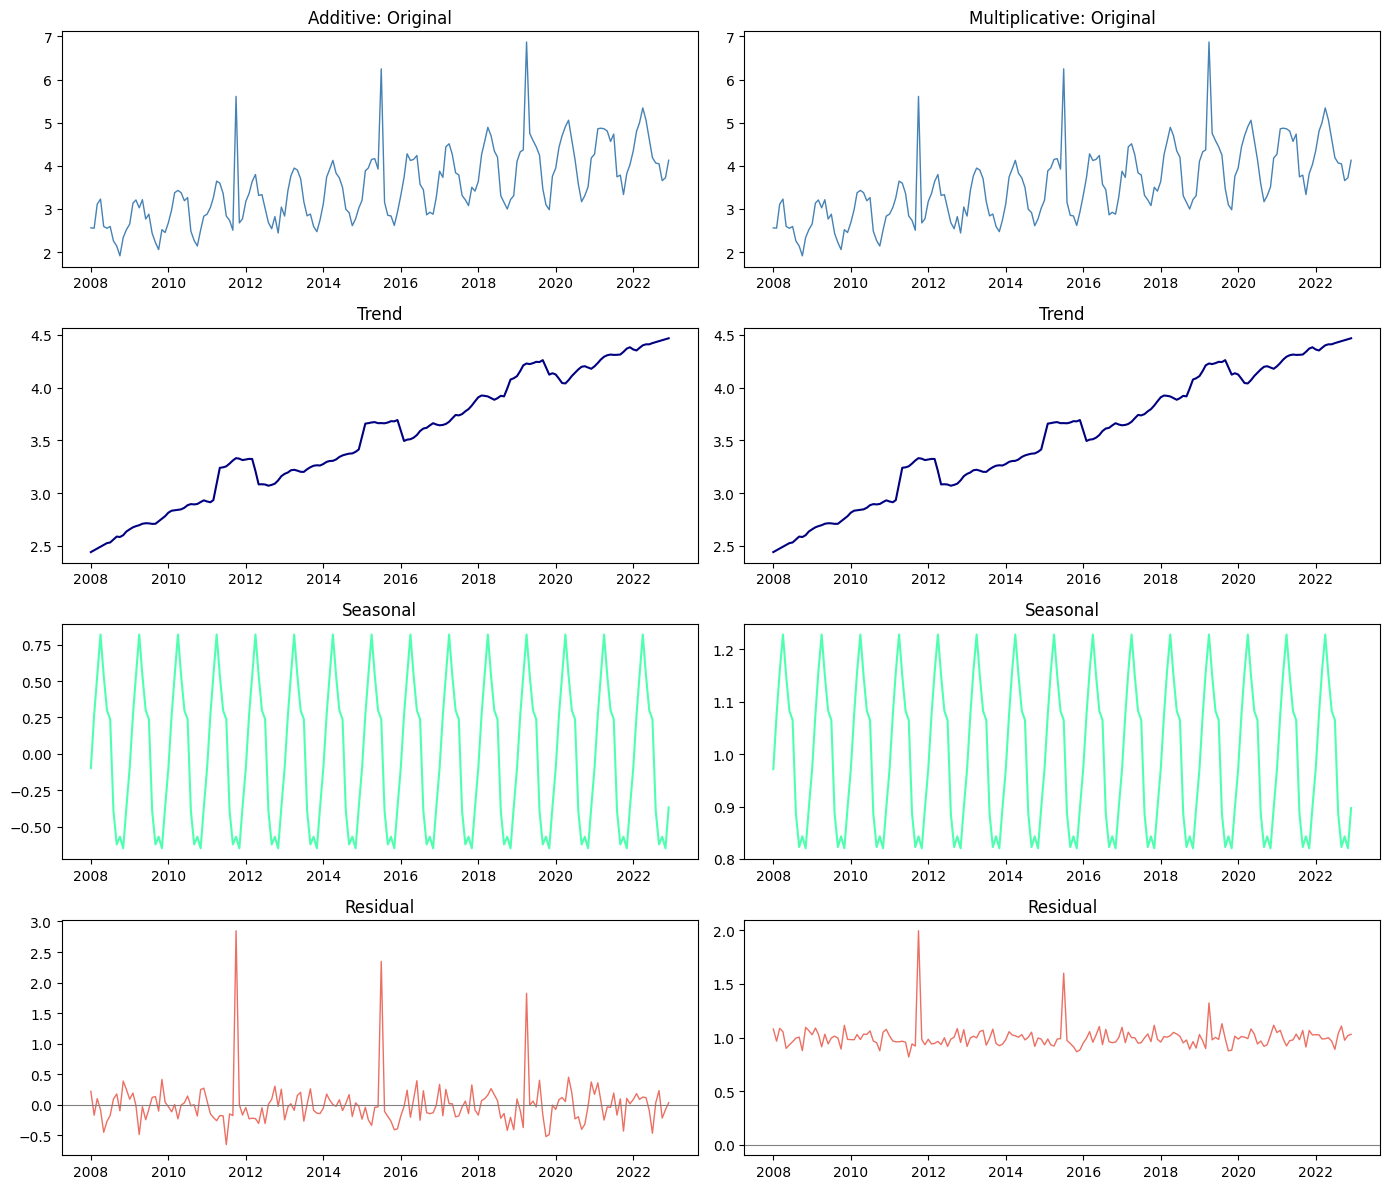

In [2]:
decomp_add = seasonal_decompose(ts, model="additive", period=12, extrapolate_trend="freq")
decomp_mul = seasonal_decompose(ts, model="multiplicative", period=12, extrapolate_trend="freq")
fig, axes = plt.subplots(4,2,figsize=(14,12))
for col, (decomp, label) in enumerate([(decomp_add,"Additive"),(decomp_mul,"Multiplicative")]):
    axes[0,col].plot(ts, color="steelblue", lw=1)
    axes[0,col].set_title(f"{label}: Original")
    axes[1,col].plot(decomp.trend, color="navy", lw=1.5)
    axes[1,col].set_title("Trend")
    axes[2,col].plot(decomp.seasonal, color="#4fffb0", lw=1.5)
    axes[2,col].set_title("Seasonal")
    axes[3,col].plot(decomp.resid, color="#e74c3c", lw=1, alpha=0.8)
    axes[3,col].axhline(0, color="grey", lw=0.8)
    axes[3,col].set_title("Residual")
plt.tight_layout(); plt.show()

---
## STL Decomposition (Robust)

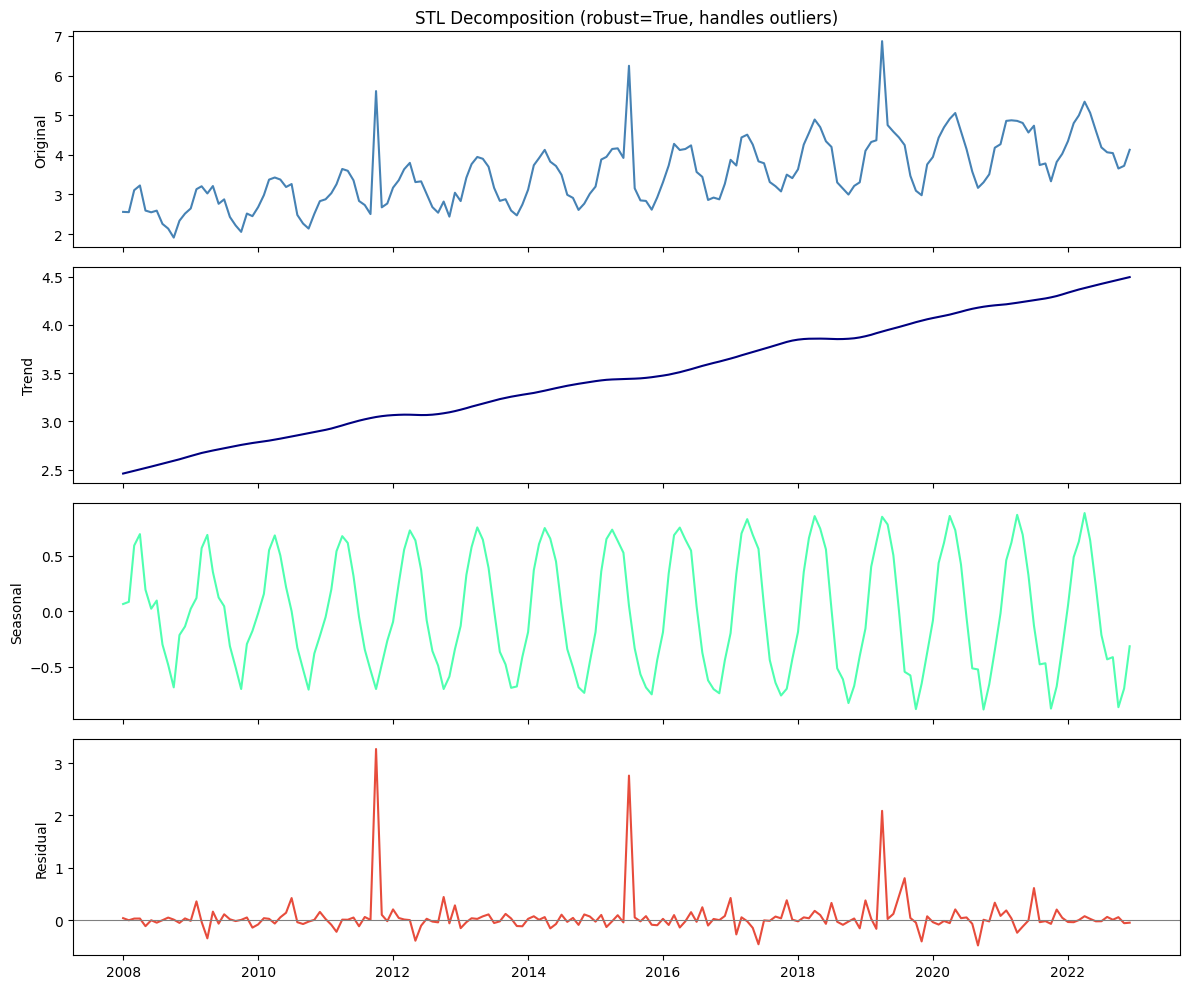

Trend  variance fraction: 0.462
Season variance fraction: 0.390
Resid  variance fraction: 0.214


In [3]:
stl = STL(ts, period=12, robust=True)
stl_result = stl.fit()
fig, axes = plt.subplots(4,1,figsize=(12,10), sharex=True)
for ax, component, label, color in zip(axes,
    [ts, stl_result.trend, stl_result.seasonal, stl_result.resid],
    ["Original","Trend","Seasonal","Residual"],
    ["steelblue","navy","#4fffb0","#e74c3c"]):
    ax.plot(component, color=color, lw=1.5)
    if label == "Residual":
        ax.axhline(0, color="grey", lw=0.8)
    ax.set_ylabel(label)
axes[0].set_title("STL Decomposition (robust=True, handles outliers)")
plt.tight_layout(); plt.show()
# Variance of components
total_var = ts.var()
print(f"Trend  variance fraction: {stl_result.trend.var()/total_var:.3f}")
print(f"Season variance fraction: {stl_result.seasonal.var()/total_var:.3f}")
print(f"Resid  variance fraction: {stl_result.resid.var()/total_var:.3f}")

---
## Seasonal Subseries Plot

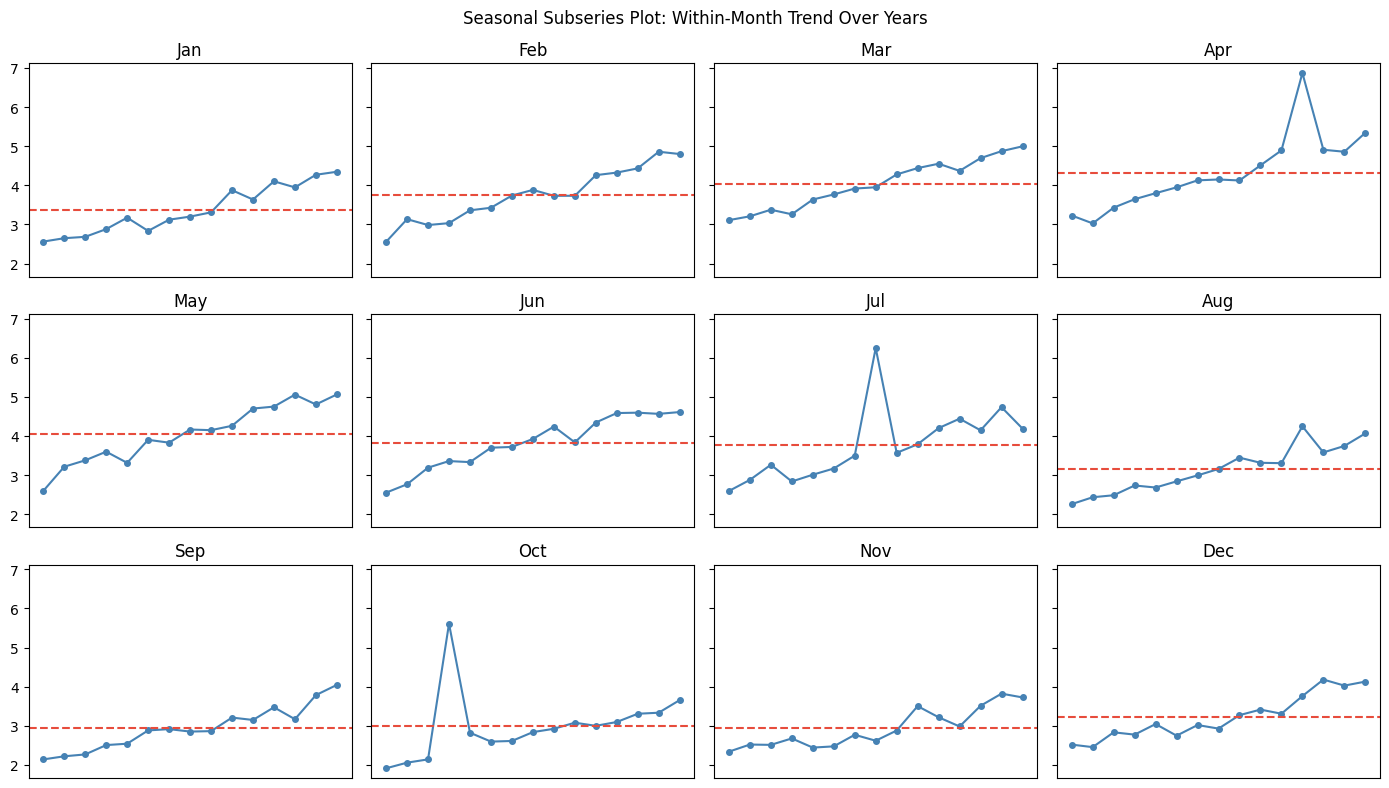

In [4]:
# Shows seasonal pattern and within-month trend
fig, axes = plt.subplots(3,4,figsize=(14,8), sharey=True)
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
for m, (ax, name) in enumerate(zip(axes.flatten(), month_names)):
    monthly = ts[ts.index.month == m+1]
    ax.plot(monthly.values, "o-", color="steelblue", markersize=4, lw=1.5)
    ax.axhline(monthly.mean(), color="#e74c3c", lw=1.5, linestyle="--")
    ax.set_title(name); ax.set_xticks([])
plt.suptitle("Seasonal Subseries Plot: Within-Month Trend Over Years")
plt.tight_layout(); plt.show()

---
## STL + Forecasting

STL+ETS forecast MAE: 0.3540


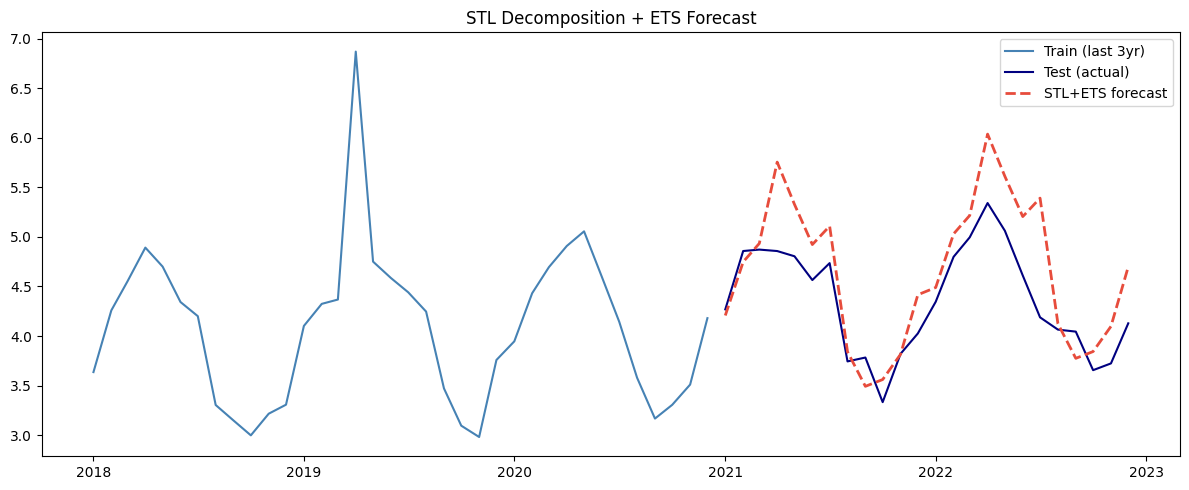

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
train_stl = ts.iloc[:156]
test_stl  = ts.iloc[156:]
# Fit STL on training, forecast trend separately, re-add seasonal
stl_tr = STL(train_stl, period=12, robust=True).fit()
trend_fc = (ExponentialSmoothing(stl_tr.trend.dropna(),
    trend="add", initialization_method="estimated")
    .fit(optimized=True).forecast(len(test_stl)))
# Use last year seasonal as forecast seasonal
seasonal_fc = stl_tr.seasonal.iloc[-12:].values
if len(test_stl) > 12:
    seasonal_fc = np.tile(seasonal_fc, int(np.ceil(len(test_stl)/12)))[:len(test_stl)]
stl_fc = pd.Series(trend_fc.values + seasonal_fc, index=test_stl.index)
from sklearn.metrics import mean_absolute_error
print(f"STL+ETS forecast MAE: {mean_absolute_error(test_stl, stl_fc):.4f}")
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train_stl.iloc[-36:], color="steelblue", lw=1.5, label="Train (last 3yr)")
ax.plot(test_stl, color="navy", lw=1.5, label="Test (actual)")
ax.plot(stl_fc,   color="#e74c3c", lw=2, linestyle="--", label="STL+ETS forecast")
ax.legend(); ax.set_title("STL Decomposition + ETS Forecast")
plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Using classical additive decomposition when seasonal amplitude is growing**  
Classical decomposition forces constant seasonal indices across time. When the seasonal swing grows with the level of the series, classical additive decomposition will produce large and structured residuals. Use STL (which allows evolving seasonality) or multiplicative decomposition.

**2. Not using robust STL when outliers are present**  
Classical and default STL decompositions are sensitive to outliers — extreme values get absorbed into the trend component, distorting both trend and seasonal estimates. Always set `robust=True` for ecological data where storm events, equipment failures, or extreme weather are common.

**3. Interpreting decomposition residuals as white noise without checking**  
Residuals from decomposition should be structureless noise. Remaining autocorrelation in residuals indicates the decomposition model is incomplete. Always plot and check residual ACF after decomposition.

**4. Using the seasonal component for forecasting without updating**  
The seasonal component from a historical decomposition may not represent future seasonality, especially under climate change. When using decomposition for forecasting, re-estimate the seasonal component regularly as new data arrives.

**5. Confusing the period of a daily series with monthly seasonality**  
For a daily series with annual seasonality, `period=365` (or 365.25), not 12. For a monthly series with annual seasonality, `period=12`. Specifying the wrong period produces a nonsensical decomposition. Always confirm the seasonal period from the ACF before decomposing.

---
*python_methods_library - Samantha McGarrigle*